In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

import seaborn as sn

from sklearn.decomposition import PCA, FastICA

In [2]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)
totalData = li.ProcessData(pumpList,entireData,totalDataPath="../data/totalProcessedData.csv")

Pumps : #38
Runs: #57


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  totalData = pd.concat([totalData,
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  totalData = pd.concat([totalData,


In [3]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    #'ESP Vibration X',
    #'ESP Vibration Y',
    'ESP Vibration Module'
    #'ESP Power',
    #"Well_down"
    ]

pumpList = totalData["Well Run"].unique()

mainSeed = 20210505

In [4]:
def PairPlot(n,mainSeed,providedData,providedHeaders,stateName):#,npump):
    model = li.GaussianMixtureFit(providedData[providedHeaders].loc[providedData["Well_down"]==0],n,seed=mainSeed)

    providedData[stateName] = -1

    providedData.loc[providedData["Well_down"]==0, stateName] = model.predict(providedData[providedHeaders].loc[providedData["Well_down"]==0])

    # sn.pairplot((providedData.loc[(providedData["Well Run"] == pumpList[npump] )
    #     & (providedData["Well_down"] == 0),providedHeaders+[stateName]]),
    #     kind="hist",
    #     hue=stateName
    #     )
    
    sn.pairplot((providedData.loc[(providedData["Well_down"] == 0),providedHeaders+[stateName]]),
        kind="hist",
        hue=stateName
        )
    
    return model

GMM AIC: 18016456.616596833
GMM BIC: 18017982.748368226


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(


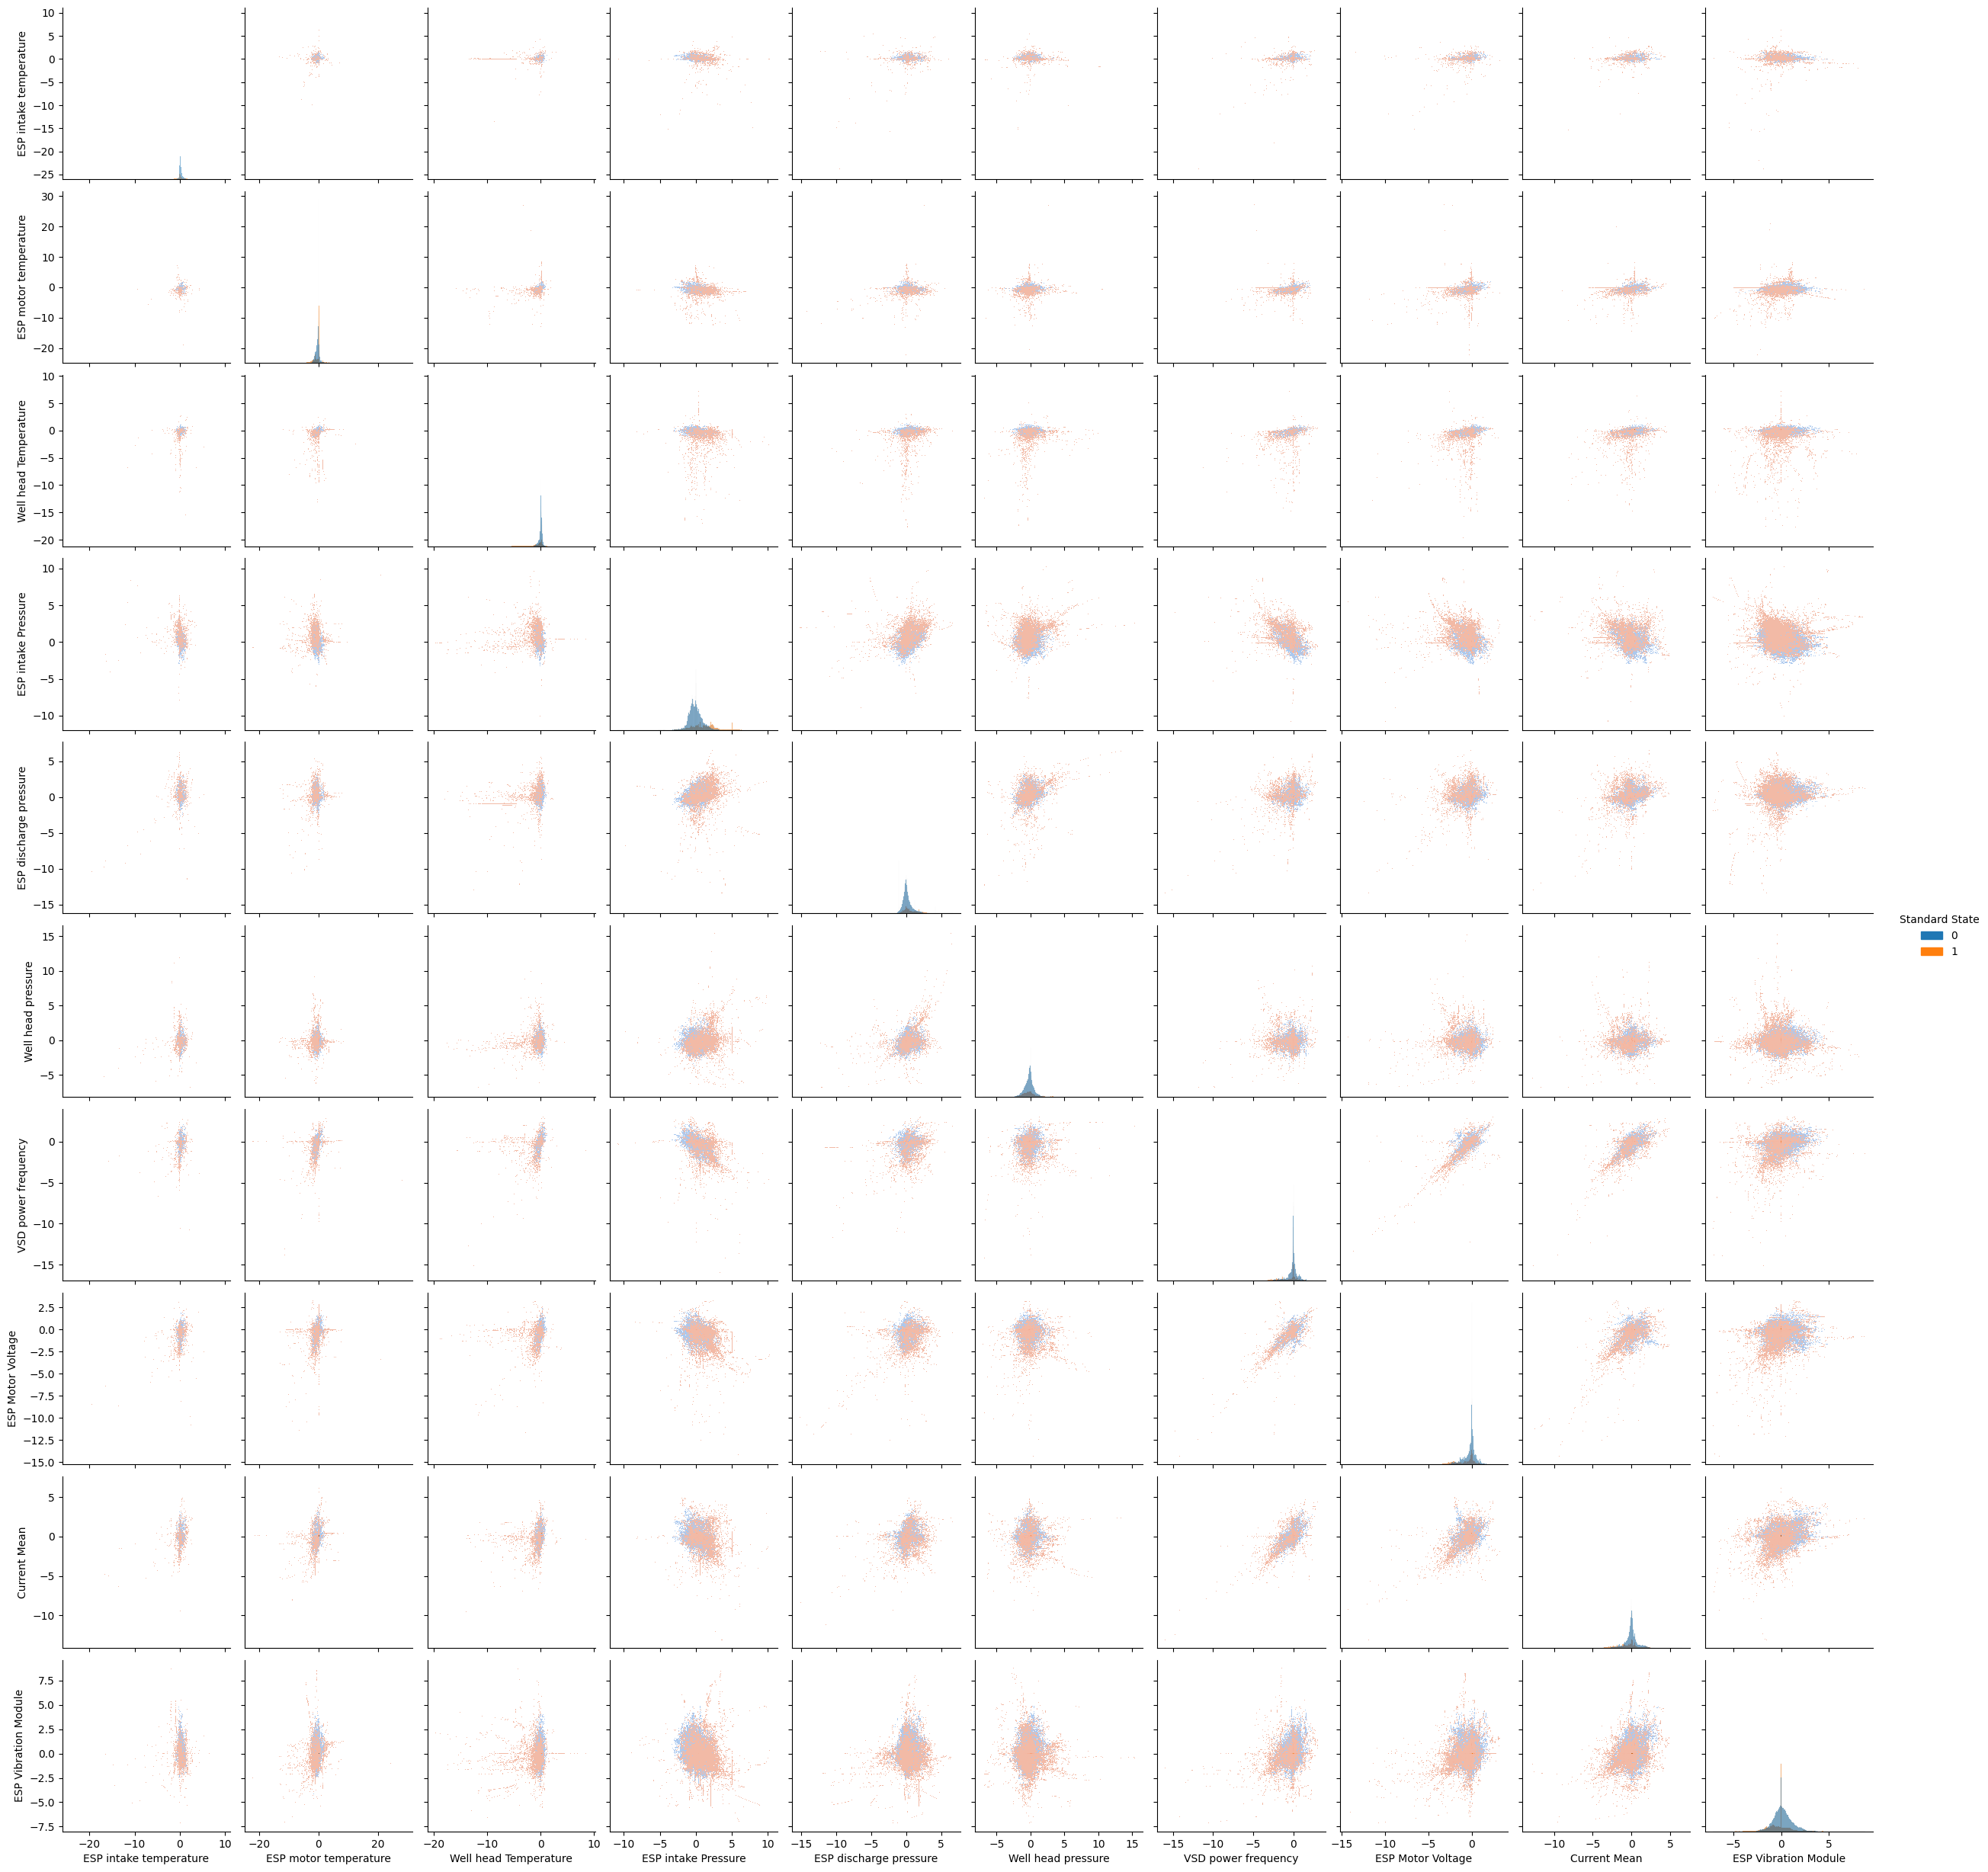

In [5]:
modelTotal = PairPlot(2,mainSeed,totalData,Headers,"Standard State")#,56)

[0.30836173 0.46982081 0.58654997 0.6831457  0.77114816 0.84691664
 0.90938841 0.94657453 0.97759068 0.99039843]


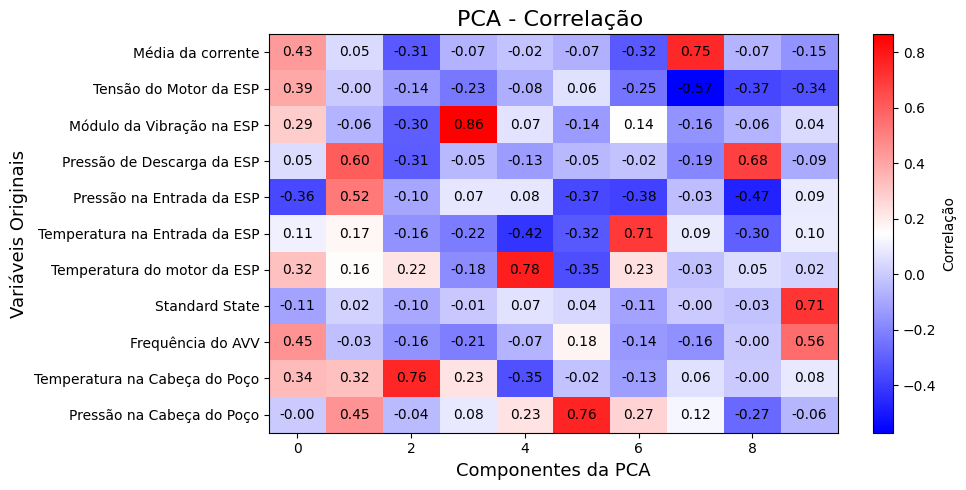

In [6]:
n = 10

operationalHeaders = li.relevantHeader(totalData)

pca = li.AutoModelApplier(PCA(n_components=n),totalData)
fig,axs = li.FigureComponents(pca,operationalHeaders, 
                              listOfNames=["PCA - Correlação ", "Correlação", "Componentes da PCA","Variáveis Originais"],
                              plotName="full_pca_pt",
                              english=False)
PCAdata, PCAHeaders = li.AutoReduce(pca,n,operationalHeaders,totalData)

PCAdata = li.ExportPCAData(PCAdata,entireData)
print(pca.explained_variance_ratio_.cumsum())

GMM AIC: 17378070.590548865
GMM BIC: 17379596.72232026


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(


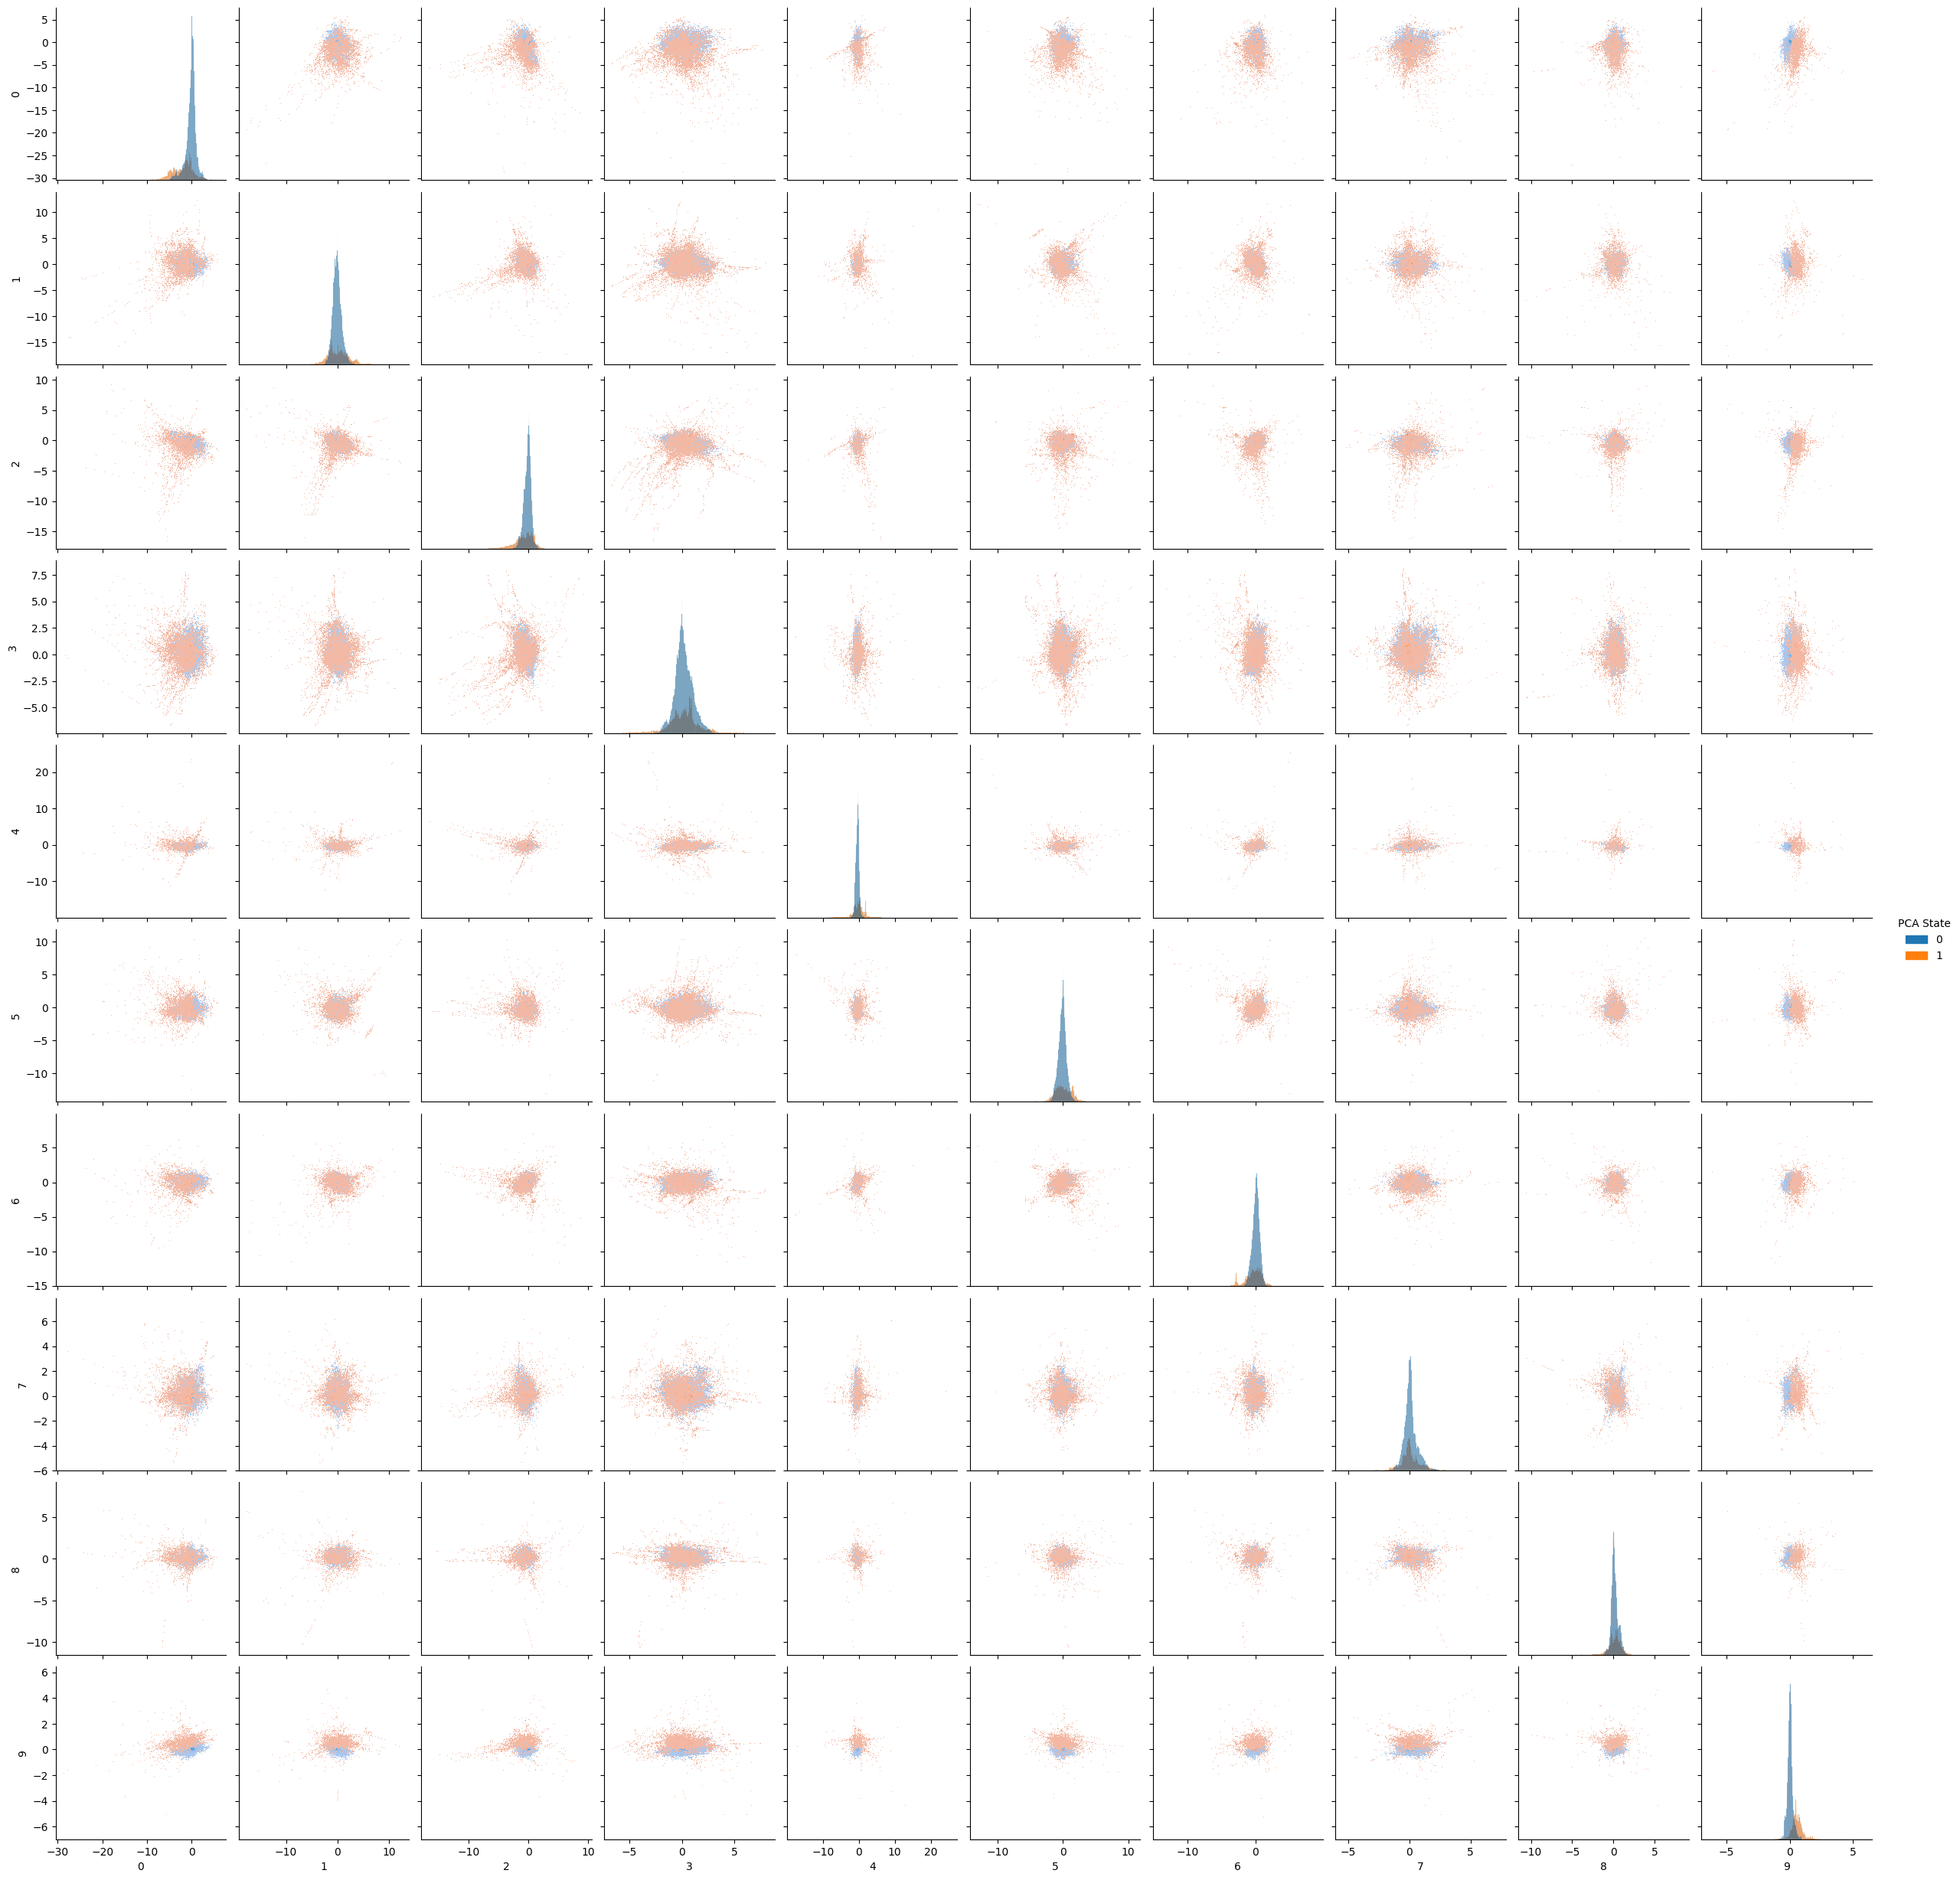

In [7]:
modelPCA = PairPlot(2,mainSeed,PCAdata,PCAHeaders,"PCA State")

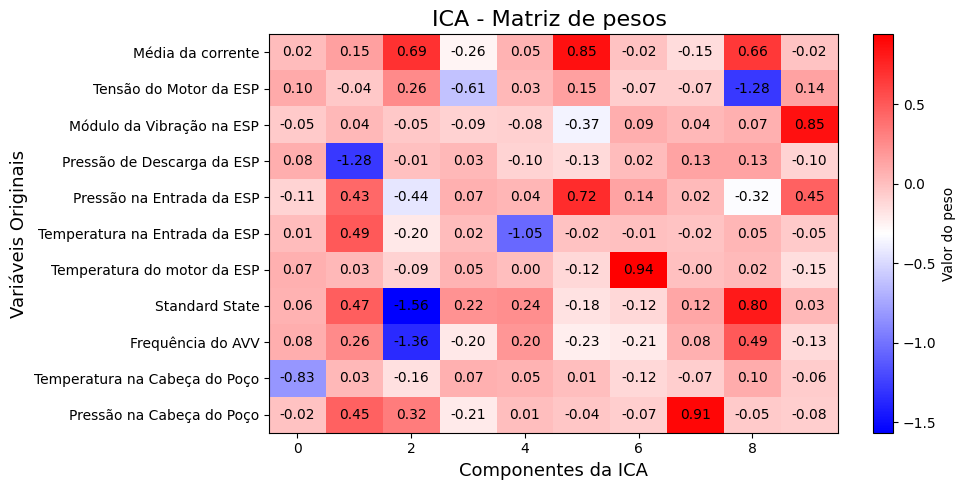

In [8]:
n =10

ica = li.AutoModelApplier(FastICA(n_components=n), totalData)

fig,axs = li.FigureComponents(ica,operationalHeaders, 
                              listOfNames=["ICA - Matriz de pesos ", "Valor do peso", "Componentes da ICA","Variáveis Originais"],
                              plotName="full_ica_pt",
                              english=False)

ICAdata,ICAHeaders = li.AutoReduce(ica,n,operationalHeaders,totalData)


ICAdata = li.ExportPCAData(ICAdata,totalData)

GMM AIC: 19031655.55529016
GMM BIC: 19033181.687061552


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(


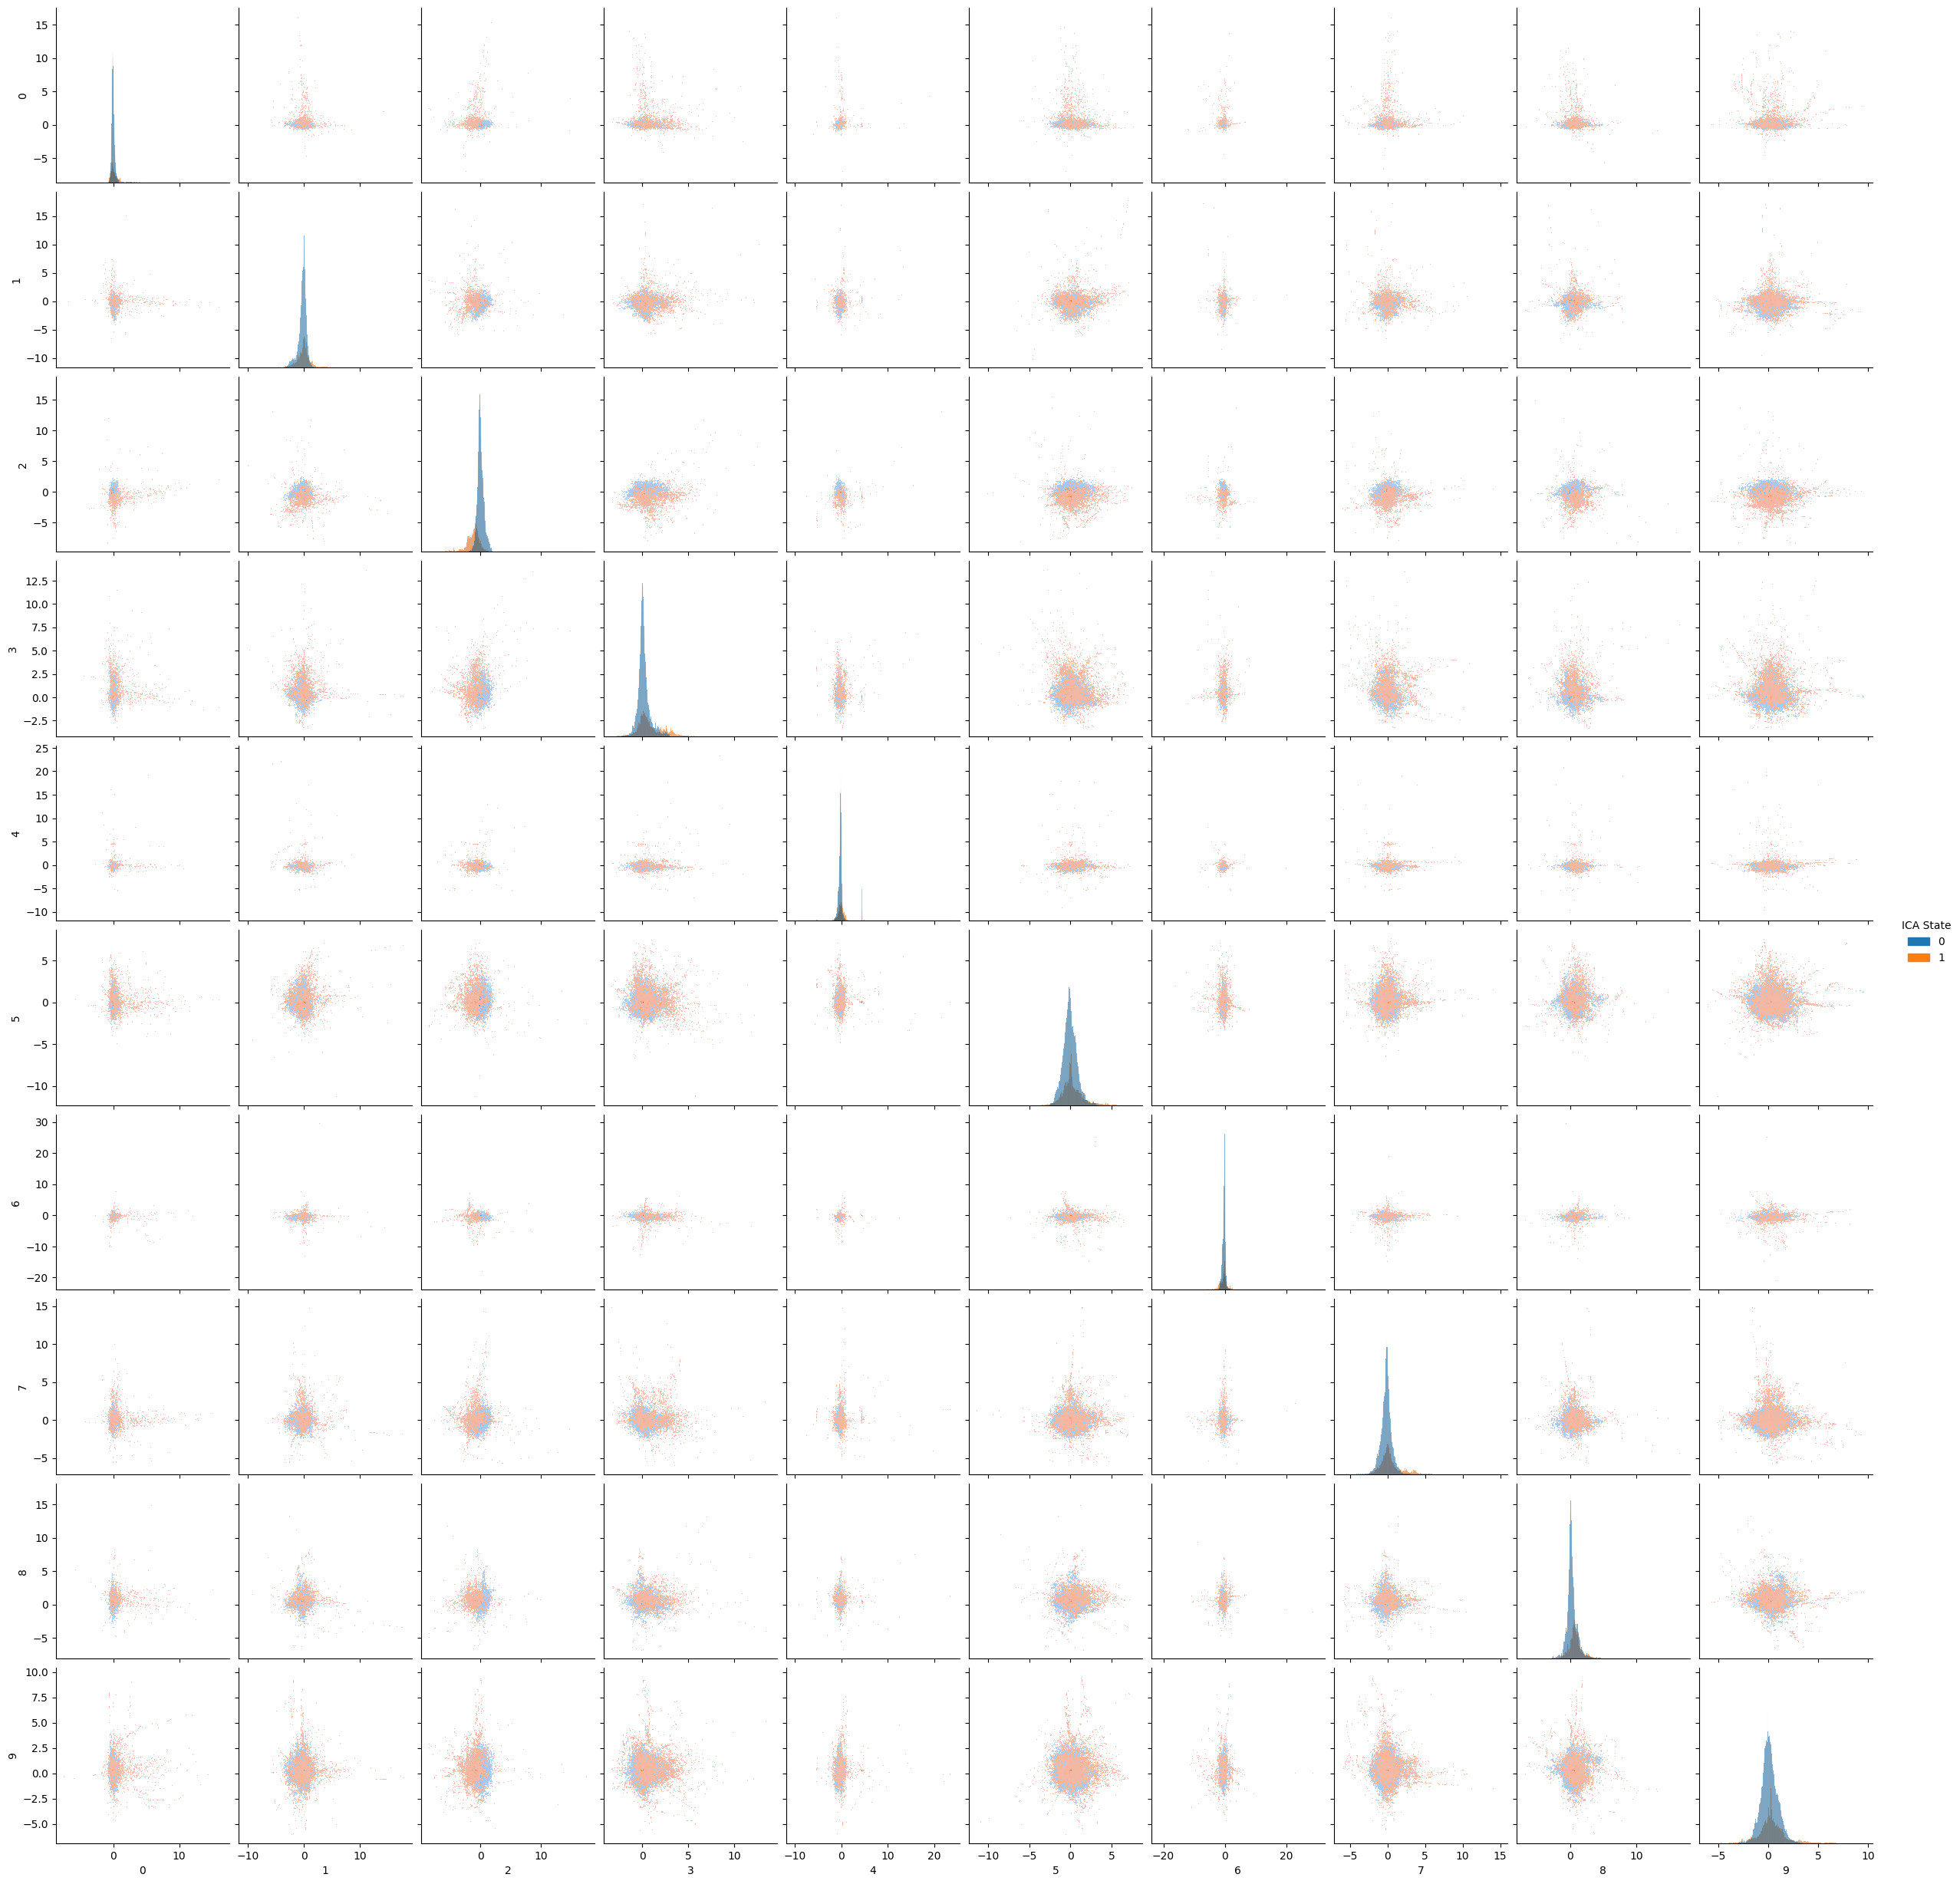

In [9]:
modelICA = PairPlot(2,mainSeed,ICAdata,ICAHeaders,"ICA State")

In [19]:

baseRunData = PCAdata
baseHeaders = PCAHeaders
stateName = "State PCA"

n = 2

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=baseRunData)

modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    params="st",
    init_params='',
    algorithm="viterbi"
    )

modelRadius.startprob_ = np.full(n, 1/n)
modelRadius.transmat_ = np.full((n, n), 1/n)

modelRadius.means_ = modelTotal.means_
modelRadius.covars__ = modelTotal.covariances_

modelRadius = li.HMMTrainer(X_train[baseHeaders],trainLength,modelRadius)

totalData1 = li.PostProcessing(modelRadius, baseRunData, modelData, baseHeaders, stateName, totalLength)
print(modelRadius.get_stationary_distribution())

totalData1[stateName] = totalData1[stateName].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))

AIC: 23452368.22908202 BIC: 23453917.660575118
[0.9726014 0.0273986]


In [16]:
totalData1.loc[totalData1["State Total"]==1]

,Well Run,VSD power frequency,ESP motor temperature,ESP intake Pressure,Water Cut @ 20degC - 1 atm,ESP intake temperature,ESP discharge pressure,Choke Opening,Well head pressure,Well head Temperature,...,Well aligned to Train B,ESP Motor Voltage,Well_down,Pump Info,Failure Info,Failure,Current Mean,ESP Vibration Module,Standard State,State Total
index,,,,,,,,,,,,,,,,,,,,,


ValueError: No objects to concatenate

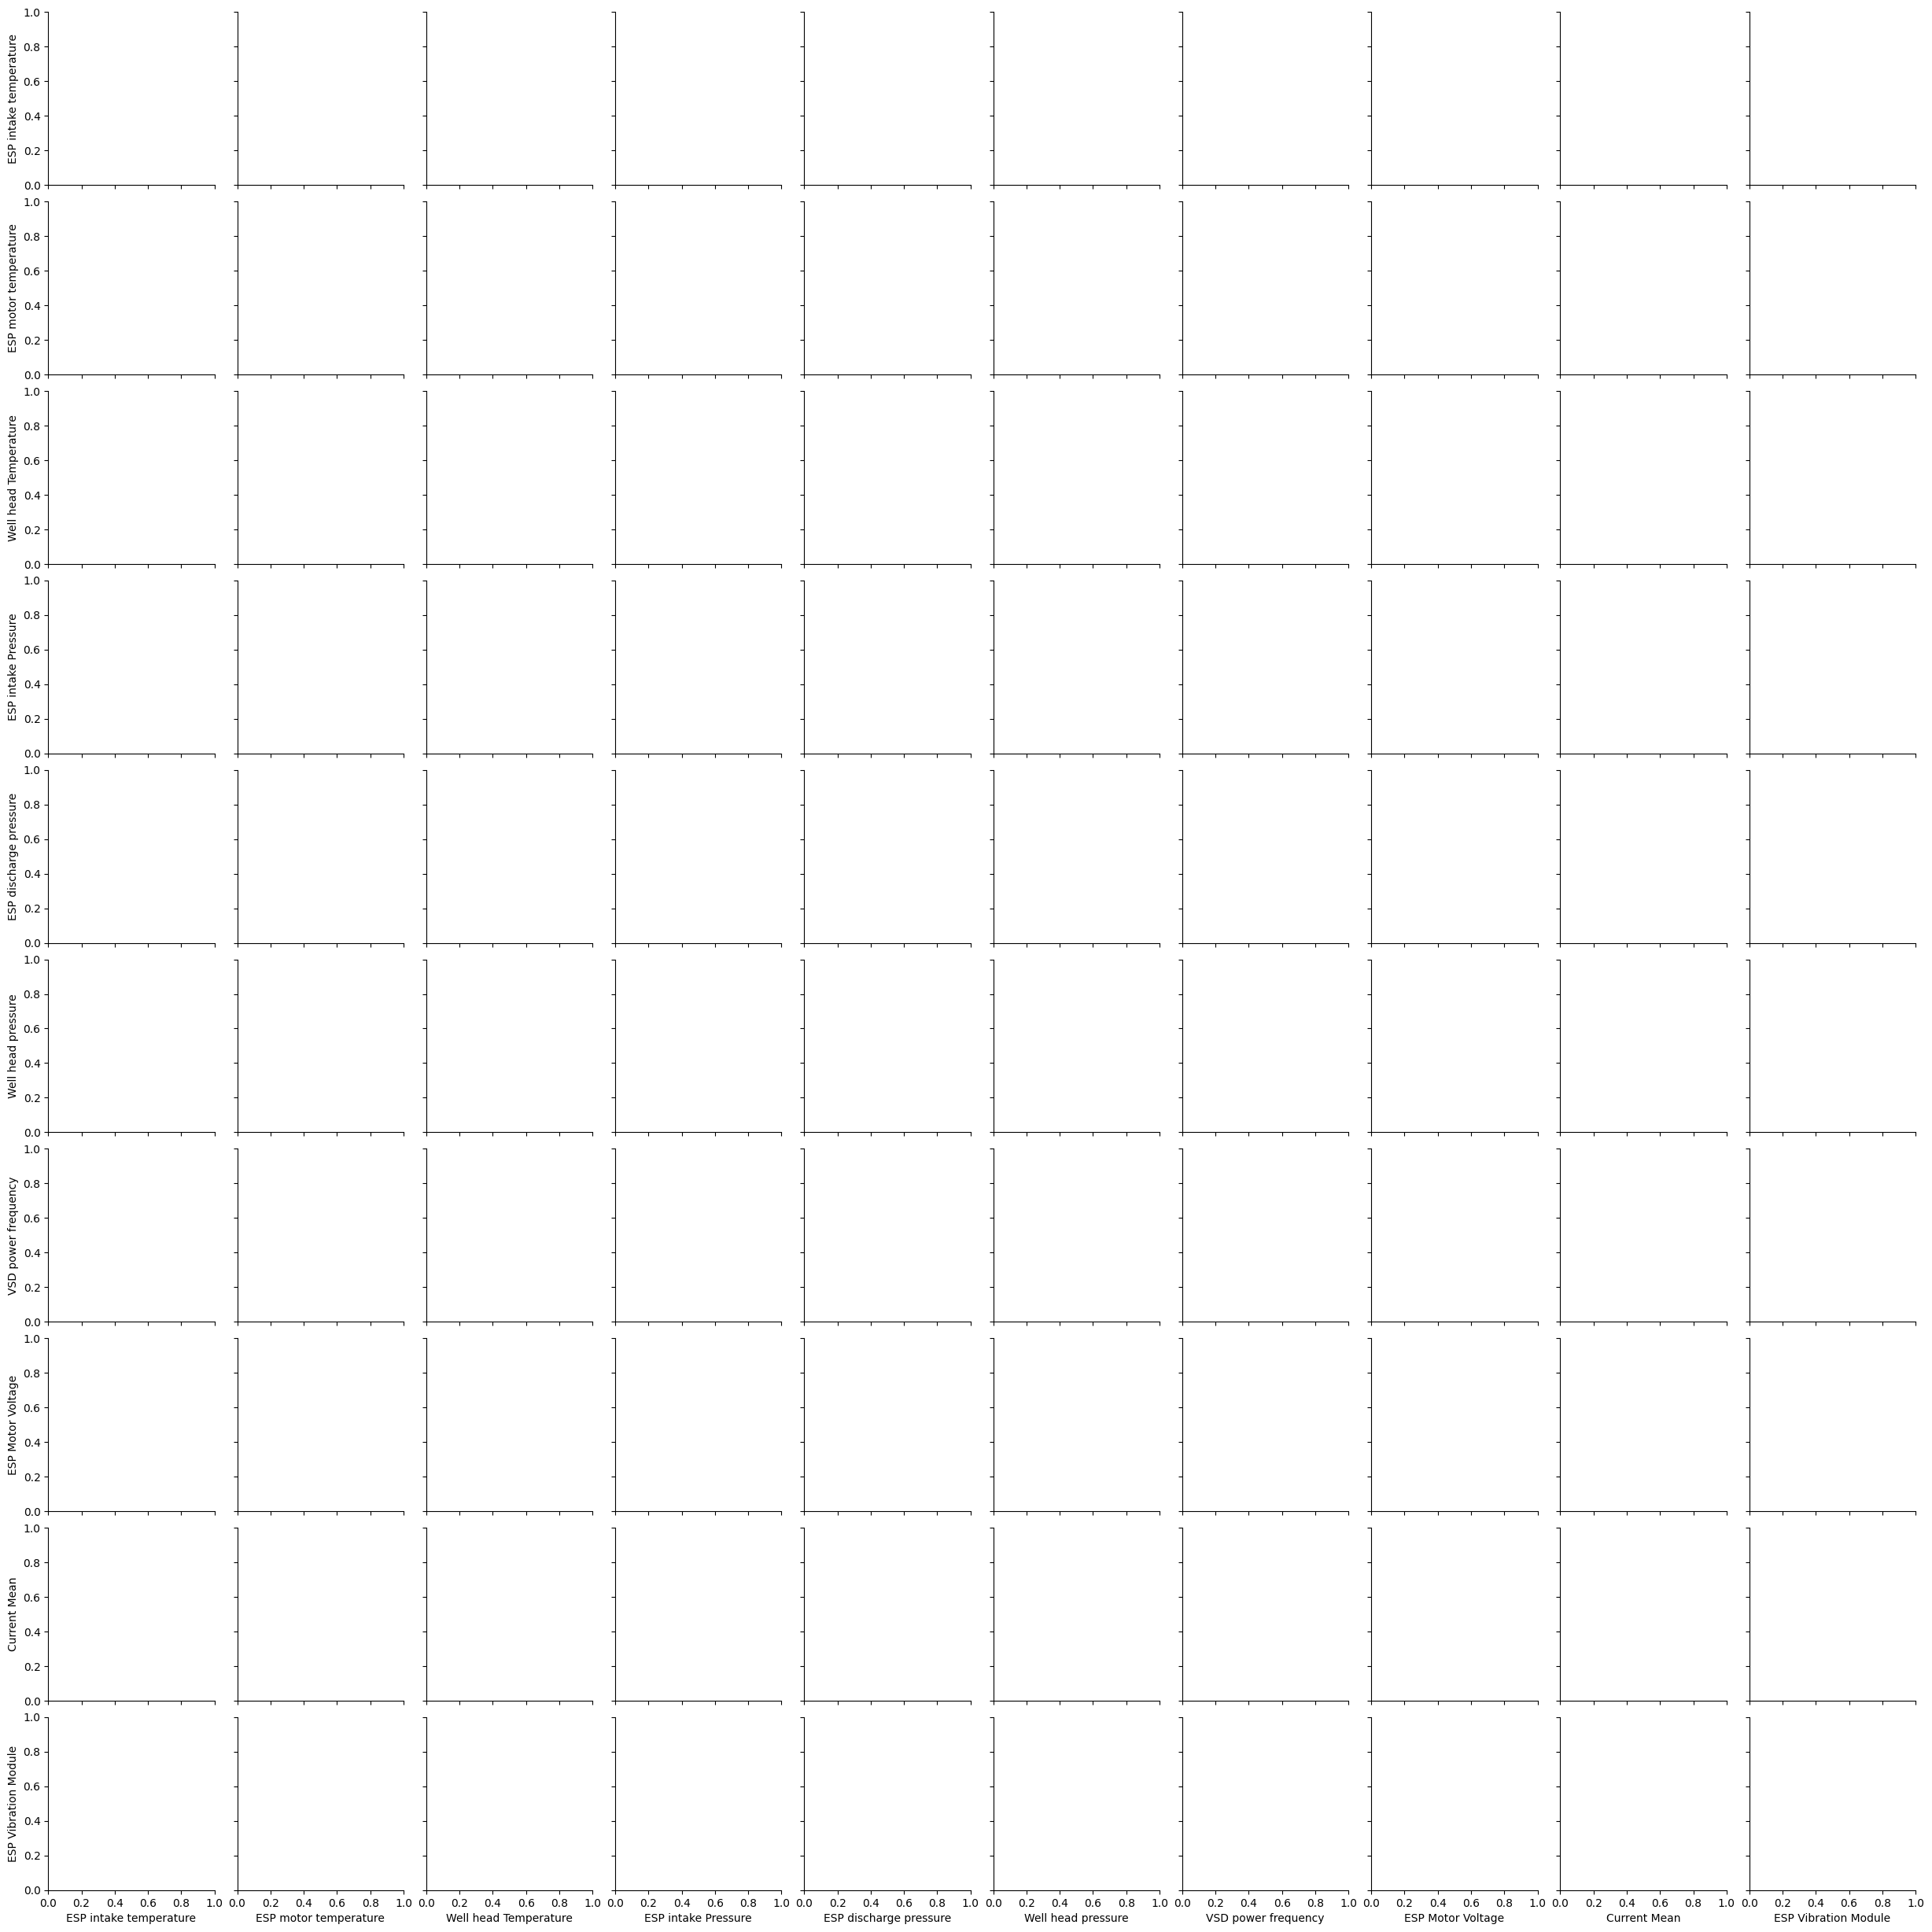

In [13]:
sn.pairplot((totalData1.loc[(totalData1["Well_down"] == 0),Headers+["State Total"]]),
    kind="hist",
    hue="State Total"
    )
    